Best k: 9 
Best avg test accuracy: 0.9780000000000001


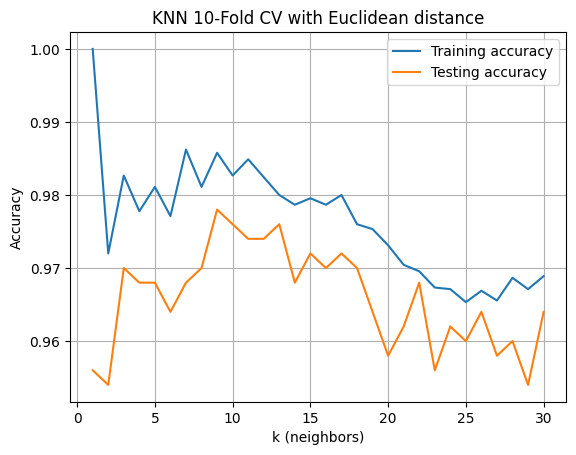

Manhattan best k: 17
Manhattan best avg test accuracy: 0.984


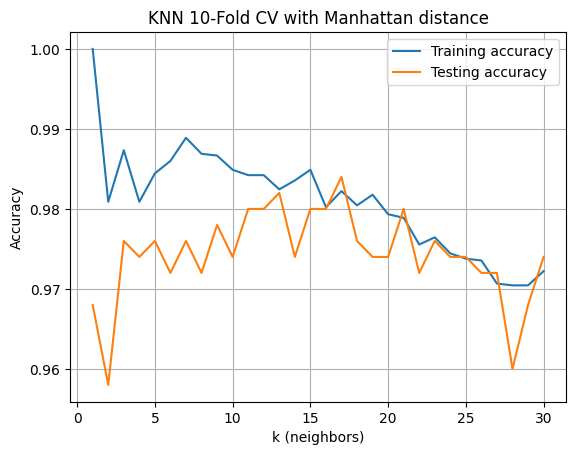

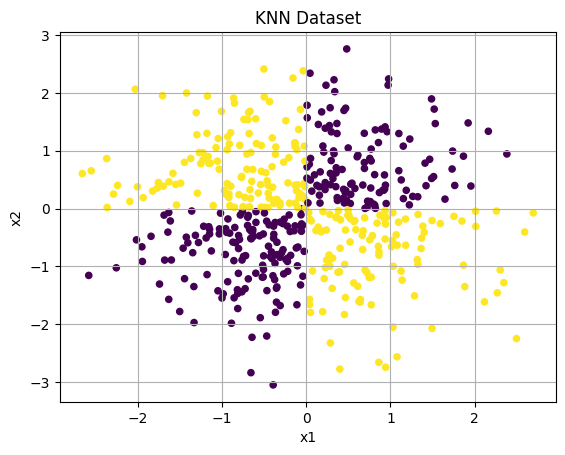

In [8]:

#part 1 KNN

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

#loading the data
# Input file
dataset1 = pd.read_csv("datasets/KNNClassifierInput.csv")  
X = dataset1.to_numpy(dtype=float)

# Output file
dataset2 = pd.read_csv("datasets/KNNClassifierOutput.csv") 
Y = dataset2["Class"].astype(float).astype(int).to_numpy()

#checking
# print(dataset1.shape, dataset2.shape)
# print(X.shape, Y.shape)
# print("Unique labels:", np.unique(Y))

#distance calculation (minkowski :))
def minkowski_distance(x, XTraining, p=2):
    
    differences = np.abs(XTraining - x)  

    if p == 1:
        # manhattan
        return np.sum(differences, axis=1)

    # normal Minkowski 
    return np.sum(differences ** p, axis=1) ** (1 / p)

a = X[0]          # one (x, y)
Xtrain = X[1:6]   # five (x, y) points

#check
# print(minkowski_distance(a, Xtrain, p=2))
# print(minkowski_distance(a, Xtrain, p=1))

#predicting one point
def knn_predict_one(x_query, X_train, Y_train, k, p=2):
    dists = minkowski_distance(x_query, X_train, p=p)
    k = min(k, len(X_train))   #maybe remove cuz no need since k=1-30
    nn_idx = np.argpartition(dists, kth=k-1)[:k]
    nn_labels = Y_train[nn_idx]

    s = np.sum(nn_labels)
    return 1 if s >= 0 else -1

X_train = X[10:]
Y_train = Y[10:]
x_query = X[0]

#checking
# print("Predicted:", knn_predict_one(x_query, X_train, Y_train, k=3, p=2))
# print("True label:", Y[0])

#predicting many points
def knn_predict_many(X_query, X_train, Y_train, k, p=2):
    predict = []
    for x in X_query:
        predict.append(knn_predict_one(x, X_train, Y_train, k, p))
    return np.array(predict)

predict = knn_predict_many(X[:5], X[10:], Y[10:], k=3, p=2)
# checking
# print("predict:", predict)
# print("True :", Y[:5])

#computing the accuracy
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

#computing training accuracy and testing accuracy for one fold 
def fold_tr_te_accuracy_knn(X, Y, train_idx, test_idx, k, p=2):
    X_train = X[train_idx]
    Y_train = Y[train_idx]
    X_test  = X[test_idx]
    Y_test  = Y[test_idx]

    # Test accuracy 
    y_test_pred = knn_predict_many(X_test, X_train, Y_train, k, p)
    test_acc = accuracy(Y_test, y_test_pred)

    # Training accuracy
    y_train_pred = knn_predict_many(X_train, X_train, Y_train, k, p)
    train_acc = accuracy(Y_train, y_train_pred)

    return train_acc, test_acc

# train_idx = np.arange(10, len(X))
# test_idx = np.arange(0, 10)

# tr_acc, te_acc = fold_tr_te_accuracy_knn(X, Y, train_idx, test_idx, k=3, p=2)
# print("Train acc:", tr_acc)
# print("Test acc :", te_acc)

#average training and testing accuracy over 10 folds
def cross_validate_knn(X, Y, k, p=2, num_folds=10, seed=42):
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

    train_accs = []
    test_accs = []

    for train_idx, test_idx in kf.split(X):
        tr_acc, te_acc = fold_tr_te_accuracy_knn(X, Y, train_idx, test_idx, k, p)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

    return float(np.mean(train_accs)), float(np.mean(test_accs))

# tr, te = cross_validate_knn(X, Y, k=3, p=2)
# print("Avg train:", tr)
# print("Avg test :", te)

#for k = 1 to 30
ks = np.arange(1, 31)

train_curve = []
test_curve = []

for k in ks:
    tr, te = cross_validate_knn(X, Y, k=k, p=2)
    train_curve.append(tr)
    test_curve.append(te)
    # print(f"k={k:2d}  train={tr:.4f}  test={te:.4f}")

train_curve = np.array(train_curve)
test_curve = np.array(test_curve)

best_idx = int(np.argmax(test_curve))
best_k = int(ks[best_idx])
best_test = float(test_curve[best_idx])
print("Best k:", best_k, "\nBest avg test accuracy:", best_test)

#graphing 
plt.figure()
plt.plot(ks, train_curve, label="Training accuracy")
plt.plot(ks, test_curve, label="Testing accuracy")
plt.xlabel("k (neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN 10-Fold CV with Euclidean distance")
plt.legend()
plt.grid(True)
plt.show()

train_curve_m = []
test_curve_m = []

for k in ks:
    tr, te = cross_validate_knn(X, Y, k=k, p=1)
    train_curve_m.append(tr)
    test_curve_m.append(te)

train_curve_m = np.array(train_curve_m)
test_curve_m = np.array(test_curve_m)

train_curve_m = np.array(train_curve_m)
test_curve_m = np.array(test_curve_m)

best_idx_m = int(np.argmax(test_curve_m))
best_k_m = int(ks[best_idx_m])
best_test_m = float(test_curve_m[best_idx_m])

print("Manhattan best k:", best_k_m)
print("Manhattan best avg test accuracy:", best_test_m)

#graphing
plt.figure()
plt.plot(ks, train_curve_m, label="Training accuracy")
plt.plot(ks, test_curve_m, label="Testing accuracy")
plt.xlabel("k (neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN 10-Fold CV with Manhattan distance")
plt.legend()
plt.grid(True)
plt.show()

#scatterplot to show how data is scattered
Y01 = ((Y + 1) // 2)

plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y01, s=20)
plt.title("KNN Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()


Part 1

▪ Report the k-fold cross-validation accuracy (the number of correctly predicted data points to the
total number of data points). 
The 10-fold cross-validation accuracy for euclidian distance was 97.8% and for manhattan distance it was 98.4%. 

▪ Select the best K and comment on the performance of the K-Nearest Neighbours
classifier.
For euclidian distance the best k was found to be k=9, while for manhattan distance it was k=17. 

▪ Explain which value of k you would choose and why.
I would choose k=14 for manahttan distance, since a very small k like 1 or 2 leads to very high training accuracy but lower testing accuracy, and results in overfitting(as we can see in boht the graphs for manhattan and euclidian distance measures). Also, if the k value is too high, both the training and the testing accuracies become worse, resulting in underfitting (as we can see with the general trend in both graphs showing that the lines are going down). k=17 with manhattan distance measure gives the highest testing accuracy and does not overfit or underfit. 

▪ Try different distance measures (e.g. Euclidean, Manhattan) and explain
your observations. Hint: Is KNN overtrained or undertrained?
Manhattan distance resulted in slightly better accuracy, with 98.4% compared to 97.8% for euclidian distance. This is because of how the data is scattered. We can see from the scatterplot that the data is grid like, which manhattan distance is usually better for. 



(λ=0)
Train R2: 0.9890775543182287
Test  R2: 0.9911373029414288
0.9812469495253884 0.9869450689013936
Lambda = 0
Avg Train R2: 0.9907977188193626
Avg Test  R2: 0.9798046304368704
lambda=  1  train=0.9902  test=0.9811
lambda=  2  train=0.9898  test=0.9806
lambda=  3  train=0.9893  test=0.9800
lambda=  4  train=0.9887  test=0.9792
lambda=  5  train=0.9880  test=0.9783
lambda=  6  train=0.9873  test=0.9774
lambda=  7  train=0.9865  test=0.9763
lambda=  8  train=0.9857  test=0.9751
lambda=  9  train=0.9848  test=0.9739
lambda= 10  train=0.9840  test=0.9727
lambda= 11  train=0.9830  test=0.9714
lambda= 12  train=0.9821  test=0.9700
lambda= 13  train=0.9811  test=0.9686
lambda= 14  train=0.9801  test=0.9672
lambda= 15  train=0.9790  test=0.9658
lambda= 16  train=0.9779  test=0.9643
lambda= 17  train=0.9769  test=0.9628
lambda= 18  train=0.9758  test=0.9613
lambda= 19  train=0.9746  test=0.9598
lambda= 20  train=0.9735  test=0.9582
lambda= 21  train=0.9723  test=0.9566
lambda= 22  train=0.971

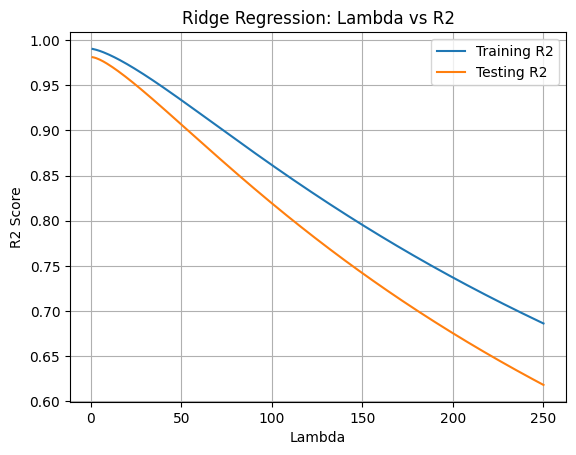

In [ ]:
#Part 2 Linear Regression

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

#loading the data
#input file
data = pd.read_csv("datasets/LinearRegression.csv")
#output file
target = pd.read_csv("datasets/LinearRegressionTarget.csv")

# Drop id column
data = data.drop(columns=["id"])

X = data.values.astype(float)
y = target["retailvalue"].values.astype(float)

#check
# print(X.shape, y.shape)
# print(data.columns)

#one fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(kf.split(X))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# λ = 0 (normal linear regression)
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

baseline_model.fit(X_train, y_train)

y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

print("(λ=0)")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test  R2:", r2_score(y_test, y_test_pred))

#computing training accuracy and testing accuracy for one fold 
def fold_tr_te_accuracy_ridge(X, y, train_idx, test_idx, lam):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    if lam == 0:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LinearRegression())
        ])
    else:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=lam))
        ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    return train_r2, test_r2

train_idx, test_idx = next(KFold(n_splits=5, shuffle=True, random_state=42).split(X))

tr, te = fold_tr_te_accuracy_ridge(X, y, train_idx, test_idx, lam=10)
print(tr, te)

#cross validation 5 fold
def cross_validate_ridge(X, y, lam, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    train_scores = []
    test_scores = []

    for train_idx, test_idx in kf.split(X):
        tr, te = fold_tr_te_accuracy_ridge(X, y, train_idx, test_idx, lam)
        train_scores.append(tr)
        test_scores.append(te)

    return np.mean(train_scores), np.mean(test_scores)

#lambda = 0
tr0, te0 = cross_validate_ridge(X, y, lam=0)
print("Lambda = 0")
print("Avg Train R2:", tr0)
print("Avg Test  R2:", te0)

#lambda from 1-250
lambdas = np.arange(1, 251)

train_curve = []
test_curve = []

for lam in lambdas:
    tr, te = cross_validate_ridge(X, y, lam)
    train_curve.append(tr)
    test_curve.append(te)
    # print(f"lambda={lam:3d}  train={tr:.4f}  test={te:.4f}")

train_curve = np.array(train_curve)
test_curve = np.array(test_curve)

#best lambda
best_idx = np.argmax(test_curve)
best_lambda = lambdas[best_idx]
best_test = test_curve[best_idx]

print("Best lambda:", best_lambda)
print("Best test R2:", best_test)

#graphing
plt.figure()
plt.plot(lambdas, train_curve, label="Training R2")
plt.plot(lambdas, test_curve, label="Testing R2")
plt.xlabel("Lambda")
plt.ylabel("R2 Score")
plt.title("Ridge Regression: Lambda vs R2")
plt.legend()
plt.grid(True)
plt.show()

part 2 

▪ Report the average training and testing results without regularization for
lambda=0. Report R2 Score or Mean Squared Error.
The average training results without regularization (lambda = 0) were R^2 = 0.9907977188193626.
And the average testing results also without regularization (lambda = 0) were R^2 = 0.9911373029414288.

▪ Report additional results by varying the lambda hyperparameter. Use the
following values for lambda between 1 to 250. Report R2 Score or Mean Squared
Error. You can show these results on a graph or a table.
As we can see from the graph, as lambda increases, both the R^2 scores for training and for testing decrease. This happens because larger values of lambda mean stronger regularization, which shrinks the weight too much. This makes the model bad at predicting. 

▪ Report the best results on the best lambda and explain your observation.
The best lambda was found to be 1, and the best R^2 score was 0.9810691252078092. This is because a small amount of regularization when lambda is 1 makes the model’s generalization slightly better by preventing overfitting. It stabilizes the regression coefficients without making the model too simple. But if lambda becomes too large then the model becomes underfitted, as we can see from the graph. 


In [6]:
#part 3 Logistic regression

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

#load the data
df = pd.read_csv("datasets/LogisticRegression.csv", header=None)

# Separate label first
y = df.iloc[:, 8].values.astype(int)

# Take only feature columns
X_df = df.iloc[:, :8]

X_df = pd.get_dummies(X_df, columns=[0])

X = X_df.values.astype(float)

#checking
print(X.shape, y.shape)
print("Class counts:", np.unique(y, return_counts=True))

unique, counts = np.unique(y, return_counts=True)
# print(dict(zip(unique, counts)))


kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_idx, test_idx = next(kf.split(X))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy :", accuracy_score(y_test, test_pred))
print("Train F1:", f1_score(y_train, train_pred))
print("Test F1 :", f1_score(y_test, test_pred))

##computing training accuracy and testing accuracy for one fold logistic regression
def fold_tr_te_accuracy_logistic_regression(X, y, train_idx, test_idx):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    return (
        accuracy_score(y_train, train_pred),
        accuracy_score(y_test, test_pred),
        f1_score(y_train, train_pred),
        f1_score(y_test, test_pred),
    )

#10 fold cross validation
def cross_validate_logistic_regression(X, y, n_folds=10):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    train_accs, test_accs = [], []
    train_f1s, test_f1s = [], []

    for train_idx, test_idx in kf.split(X):
        tr_acc, te_acc, tr_f1, te_f1 = fold_tr_te_accuracy_logistic_regression(X, y, train_idx, test_idx)
        train_accs.append(tr_acc); test_accs.append(te_acc)
        train_f1s.append(tr_f1);   test_f1s.append(te_f1)

    train_accs = np.array(train_accs); test_accs = np.array(test_accs)
    train_f1s  = np.array(train_f1s);  test_f1s  = np.array(test_f1s)

    print("Accuracy:")
    print("Train mean:", train_accs.mean(), "std:", train_accs.std(ddof=1))
    print("Test  mean:", test_accs.mean(),  "std:", test_accs.std(ddof=1))
    print("Test  min :", test_accs.min(),   "Test max:", test_accs.max())

    print("\nF1-score:")
    print("Train mean:", train_f1s.mean(), "std:", train_f1s.std(ddof=1))
    print("Test  mean:", test_f1s.mean(),  "std:", test_f1s.std(ddof=1))
    print("Test  min :", test_f1s.min(),   "Test max:", test_f1s.max())
    
cross_validate_logistic_regression(X, y)

(100000, 10) (100000,)
Class counts: (array([0, 1]), array([91500,  8500]))
Train accuracy: 0.9602888888888889
Test accuracy : 0.9593
Train F1: 0.7275914634146341
Test F1 : 0.7262945527908541
Accuracy:
Train mean: 0.9601855555555554 std: 0.0001543204938263723
Test  mean: 0.9602000000000002 std: 0.001349073756323192
Test  min : 0.9585 Test max: 0.9628

F1-score:
Train mean: 0.7276619145826423 std: 0.001484978117627507
Test  mean: 0.7276650913428455 std: 0.012641818615930774
Test  min : 0.710801393728223 Test max: 0.7542932628797886


Part 3 
Report the results as follows:
▪ Accuracy for training and testing
Training accuracy:
0.96019 

Testing accuracy
0.96020 

• Standard deviation for accuracy (both training and testing):
training std = 0.00015
testing std = 0.00135

▪ F-measure for training and testing
Training F1 
0.72766 

Testing F1:
0.72767

• Standard deviation for f-measure (both training and testing):
training std = 0.00148
testing std = 0.01264

▪ Highest or lowest testing scores for accuracy and f-measure among 10 fold iterations

Highest testing accuracy: 0.9628

Lowest testing accuracy: 0.9585

Highest testing F1-score: 0.7543

Lowest testing F1-score:  0.7108

▪ Which measure (accuracy or f-measure) provides a more accurate
representation of the logistic regression classifier performance? Explain your
answer.
The F-measure provides a more accurate representation of the logistic regression classifier performance than accuracy for this dataset because it is extremely imbalanced, with 91,500 samples of class 0 and only 8,500 samples of class 1. Because of this, a classifier can achieve very high accuracy by predicting the majority class most of the time. This is why we got the accuracy range as 0.9585 to 0.9628. 
The F-measure focuses on how well the model detects the minority class (class 1), instead of just being influenced by the majority class (class 0). This is why teh range for the F-measure was 0.7108 to 0.7543, which is a better picture of the model’s performance. 



KNN (k=9, Euclidean)
Train err mean/std: 0.014222222222222202 0.003658989343771422
Test  err mean/std: 0.02200000000000002 0.01988857852023508

Logistic Regression
Train err mean/std: 0.5428888888888889 0.03222094505770311
Test  err mean/std: 0.5660000000000001 0.04903513479582209


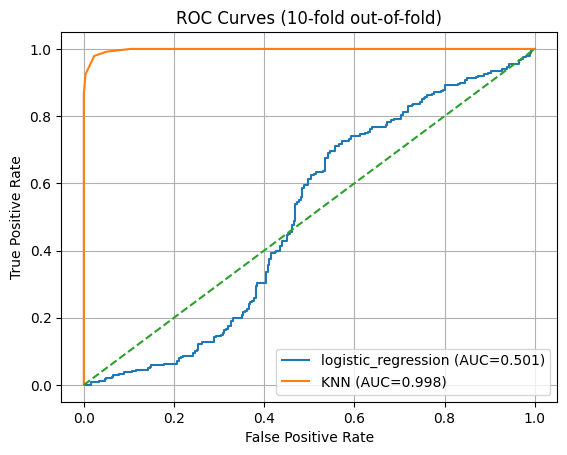

In [ ]:
#part 4 comparison between KNN and logistic regression 

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#loading the data
X = pd.read_csv("datasets/KNNClassifierInput.csv").to_numpy(dtype=float)
y_pm = pd.read_csv("datasets/KNNClassifierOutput.csv")["Class"].astype(int).to_numpy()  # -1/+1

# Convert to 0/1 for logistic and ROC
y01 = ((y_pm + 1) // 2).astype(int)
best_k = 9

#evaluate for knn
def eval_fold_knn(X, y_pm, train_idx, test_idx, k=9, p=2):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_pm[train_idx], y_pm[test_idx]

    # test
    y_test_pred = knn_predict_many(X_test, X_train, y_train, k=k, p=p)
    test_acc = np.mean(y_test_pred == y_test)

    # train
    y_train_pred = knn_predict_many(X_train, X_train, y_train, k=k, p=p)
    train_acc = np.mean(y_train_pred == y_train)

    train_err = 1 - train_acc
    test_err = 1 - test_acc
    return train_err, test_err

#logistic regression fold eval
def eval_fold_logistic_regression(X, y01, train_idx, test_idx):
    X_train, X_test = X[train_idx], X[test_idx]
    # y_train, y_test = y01[train_idx], y01[test_idx]

    y_train = y01[train_idx]
    y_test  = y01[test_idx]

    model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, C=1.0))
])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_err = 1 - accuracy_score(y_train, train_pred)
    test_err  = 1 - accuracy_score(y_test, test_pred)
    return train_err, test_err

#10 fold cross validation


def cv_errors_knn(X, y_pm, k=9, p=2):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    tr, te = [], []
    for train_idx, test_idx in kf.split(X):
        tr_err, te_err = eval_fold_knn(X, y_pm, train_idx, test_idx, k=k, p=p)
        tr.append(tr_err); te.append(te_err)
    tr = np.array(tr); te = np.array(te)
    return tr.mean(), tr.std(ddof=1), te.mean(), te.std(ddof=1)

def cv_errors_logistic_regression(X, y01):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    tr, te = [], []
    for train_idx, test_idx in kf.split(X):
        tr_err, te_err = eval_fold_logistic_regression(X, y01, train_idx, test_idx)
        tr.append(tr_err); te.append(te_err)
    tr = np.array(tr); te = np.array(te)
    return tr.mean(), tr.std(ddof=1), te.mean(), te.std(ddof=1)

#print

knn_tr_m, knn_tr_s, knn_te_m, knn_te_s = cv_errors_knn(X, y_pm, k=best_k, p=2)
log_tr_m, log_tr_s, log_te_m, log_te_s = cv_errors_logistic_regression(X, y01)

print("KNN (k=9, Euclidean)")
print("Train err mean/std:", knn_tr_m, knn_tr_s)
print("Test  err mean/std:", knn_te_m, knn_te_s)

print("\nLogistic Regression")
print("Train err mean/std:", log_tr_m, log_tr_s)
print("Test  err mean/std:", log_te_m, log_te_s)

#logistic

kf = KFold(n_splits=10, shuffle=True, random_state=42)

log_scores = np.zeros(len(X))

for train_idx, test_idx in kf.split(X):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, C=1.0))
    ])
    model.fit(X[train_idx], y01[train_idx])

    lr = model.named_steps["lr"]
    proba = model.predict_proba(X[test_idx])

    #finding which column is class 1
    col1 = np.where(lr.classes_ == 1)[0][0]
    log_scores[test_idx] = proba[:, col1]

#knn 

def knn_score_prob1(X_query, X_train, y01_train, k=9, p=2):
    probs = []
    for x in X_query:
        dists = minkowski_distance(x, X_train, p=p)
        nn_idx = np.argpartition(dists, kth=k-1)[:k]
        probs.append(np.mean(y01_train[nn_idx]))  # fraction of neighbors that are 1
    return np.array(probs)

knn_scores = np.zeros(len(X))
for train_idx, test_idx in kf.split(X):
    X_train = X[train_idx]
    y_train01 = y01[train_idx]
    knn_scores[test_idx] = knn_score_prob1(X[test_idx], X_train, y_train01, k=best_k, p=2)

fpr_log, tpr_log, _ = roc_curve(y01, log_scores)
auc_log = auc(fpr_log, tpr_log)


fpr_knn, tpr_knn, _ = roc_curve(y01, knn_scores)
auc_knn = auc(fpr_knn, tpr_knn)

#graph

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"logistic_regression (AUC={auc_log:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot([0,1],[0,1],'--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (10-fold out-of-fold)")
plt.legend()
plt.grid(True)
plt.show()


Part 4
▪ Report training and testing error rates and standard deviations for both
algorithms.
KNN (k = 9, Euclidean distance)
Training error: 0.0142 
standard deviation:  0.0037
Testing error: 0.0220 
standard deviation: 0.0199

Logistic Regression
Training error: 0.5429
standard deviation: 0.0322
Testing error: 0.5660 
standard deviation: 0.0490

▪ Compare the two algorithms in terms of their performances and comment on
your observation.
The K-Nearest Neighbours classifier performed much better than Logistic Regression on this dataset, it achieved very low training and testing error rates (around 2%), showing that it was able to correctly classify almost all data points. Logistic Regression had error rates above 50%, which is very bad in comparison.
As we can see from the scatterplot in Part 1, the data forms a cross-shaped pattern where opposite quadrants belong to the same class. This means that it cannot be separated by a straight line. thats why logistic regression fails because it learns a linear decision boundary. We can see this in the ROC curve where the area under the curve or AUC is 0.501. KNN does not assume any linear boundary and classifies points based on their neighbouring points, so KNN results in very low error rates and the AUC is 0.998 which is very close to 1. 

▪ What do the standard deviations represent in the context of your results
and the classification?
Standard deviation represents how stable the algorithm is across different splits of the data, how it differs between different folds in the 10-fold cv. the smaller the std the more stable the model is. 

▪ Elaborate on how you selected the best performed parameters (E.g. k for
KNN)
I selected K = 9 because that is what we got as the best k with euclidian distance measure in part 1. 